In [15]:
# Load the quandle algebra code
load('quandles-alpha.sage')
%display latex
import snappy
from sage.knots.link import Link as SageLink
import itertools

In [16]:
def plot_the_link(pd_example):
    pd = [list(t) for t in pd_example]
    L = SageLink(pd)
    print("Link:", L)
    print("Components:", L.number_of_components())
    G = L.plot()
    show(G)

def analyze_the_knot(pd_code):
    K = SageLink(pd_code)
    arcs = K.arcs()
    arc_crossings = []
    over_arcs = []
    under_arcs = []
    under_exit = []
    n = 0
    Ks = snappy.Link(pd_code)
    crossing_signs = [c.sign for c in Ks.crossings]
    for i in pd_code: 
        n = 1
        for j in arcs:
            if i[0] in j:
                under_arcs.append(n)
            if i[1] in j:
                over_arcs.append(n)
            if i[2] in j:
                under_exit.append(n)
            n += 1
    for i in range(len(pd_code)):   
        element = [over_arcs[i],under_arcs[i],under_exit[i]]
        arc_crossings.append(element)
    plot_the_link(pd_code)
    print("original pd code is", pd_code)
    print("arcs are ", arcs)
    print("crossing signs are ", crossing_signs)
    print("over,under entering, under existing arcs at crossings are ", arc_crossings)
    return(arcs, crossing_signs, arc_crossings)

Link: Link with 1 component represented by 3 crossings
Components: 1


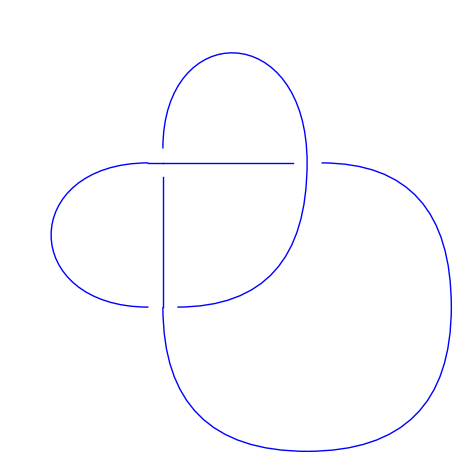

original pd code is [(1, 5, 2, 4), (5, 3, 6, 2), (3, 1, 4, 6)]
arcs are  [[6, 1], [2, 3], [4, 5]]
crossing signs are  [1, 1, 1]
over,under entering, under existing arcs at crossings are  [[3, 1, 2], [2, 3, 1], [1, 2, 3]]


In [17]:
pd_example = [(1, 5, 2, 4),                            # Example PD tuple list (trefoil-like example)
              (5, 3, 6, 2),
              (3, 1, 4, 6)]

#kinfo = analyze_pd_sage_debug(pd_example, debug=True)
# SageMath: plot a knot/link from PD code
# Sage usually accepts PD as a list of 4-lists; convert if needed:

arcs, crossing_signs, arc_crossings = analyze_the_knot(pd_example)

Link: Link with 1 component represented by 4 crossings
Components: 1


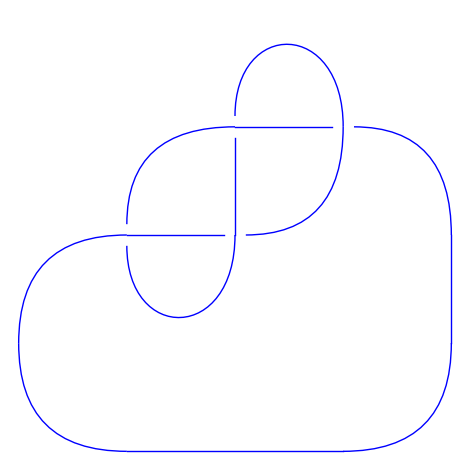

original pd code is [(4, 2, 5, 1), (8, 6, 1, 5), (6, 3, 7, 4), (2, 7, 3, 8)]
arcs are  [[1, 2], [3, 4], [5, 6], [7, 8]]
crossing signs are  [1, 1, -1, -1]
over,under entering, under existing arcs at crossings are  [[1, 2, 3], [3, 4, 1], [2, 3, 4], [4, 1, 2]]


In [18]:
pd_example = [(4, 2, 5, 1), (8, 6, 1, 5), (6, 3, 7, 4), (2, 7, 3, 8)]

#kinfo = analyze_pd_sage_debug(pd_example, debug=True)
# SageMath: plot a knot/link from PD code
# Sage usually accepts PD as a list of 4-lists; convert if needed:

arcs, crossing_signs, arc_crossings = analyze_the_knot(pd_example)

In [19]:
#number of variables may be not well defined anymore (canonicalcomponents)
# Ezra Miller
# is the number of generators the same as dimentions? maybe
# greedyn elimination method see how many there is

In [20]:
# Symbolic generator classes (from your original Codes.ipynb)

class SymGen:
    """Symbolic generator (leaf) representing a generator g<id>."""
    def __init__(self, name):
        self.name = str(name)
    def __repr__(self):
        return self.name
    def quandleUnder(self, other):
        return SymOp(self, other)
    def variables(self):
        return {self.name}
    def substitute(self, mapping):
        # mapping: name -> SymExpr (or leave as-is)
        return mapping.get(self.name, self)

class SymOp:
    """Binary operation node representing (left) ▷ (right)."""
    def __init__(self, left, right):
        self.left = left
        self.right = right
    def __repr__(self):
        return f"({self.left} ▷ {self.right})"
    def variables(self):
        return set().union(*[ getattr(self.left, 'variables')() if callable(getattr(self.left,'variables',None)) else self.left.variables(),
                              getattr(self.right, 'variables')() if callable(getattr(self.right,'variables',None)) else self.right.variables() ])
    def substitute(self, mapping):
        L = self.left.substitute(mapping) if hasattr(self.left,'substitute') else self.left
        R = self.right.substitute(mapping) if hasattr(self.right,'substitute') else self.right
        return SymOp(L, R)
    def quandleUnder(self, other):
        # nested op
        return SymOp(self, other)

In [21]:
# Helper functions for symbolic manipulation

def sym_vars(expr):
    """Get variable names from a symbolic expression."""
    if isinstance(expr, SymGen):
        return expr.variables()
    elif isinstance(expr, SymOp):
        vs_left = set(sym_vars(expr.left))
        vs_right = set(sym_vars(expr.right))
        return vs_left.union(vs_right)
    else:
        return set()

def print_sym_eq(i, lhs, rhs):
    """Pretty-print a symbolic equation."""
    print(f"Eq {i}: {lhs} == {rhs}")

def expr_vars(expr):
    """Return set of variable names occurring in SymGen/SymOp tree."""
    return getattr(expr, "variables")()

def all_vars_in_eqs(eqs):
    """Return the set of variable names appearing in equation system."""
    names = set()
    for lhs, rhs, _ in eqs:
        if hasattr(lhs, "name"):
            names.add(lhs.name)
        else:
            if hasattr(lhs, "variables"):
                names |= getattr(lhs, "variables")()
        names |= expr_vars(rhs)
    return names

def substitute_eqs(eqs, mapping, skip_index=None):
    """Apply substitution mapping to equations."""
    new_eqs = []
    for i,(lhs, rhs, index) in enumerate(eqs):
        if i == skip_index:
            continue
        new_lhs = lhs.substitute(mapping) if hasattr(lhs, "substitute") else lhs
        new_rhs = rhs.substitute(mapping) if hasattr(rhs, "substitute") else rhs
        new_eqs.append((new_lhs, new_rhs, index))
    return new_eqs

In [22]:
def build_generator_equations(arcs, crossing_signs, arc_crossings, verbose=True):
    """
    Build generator-level symbolic equalities from knot crossing information.
    
    Each crossing produces ONE generator-level equality:
      positive crossing: g_exit = g_enter ▷ g_over
      negative crossing: g_enter = g_exit ▷ g_over
    
    Parameters:
    -----------
    arcs : list
        Arc information from analyze_the_knot()
    crossing_signs : list
        +1 or -1 for each crossing
    arc_crossings : list
        [over_arc, under_enter_arc, under_exit_arc] for each crossing
    
    Returns:
    --------
    tuple: (symgens, equations)
        symgens: dict mapping arc_number -> SymGen object
        equations: list of (lhs_symexpr, rhs_symexpr, crossing_index)
    """
    
    if verbose:
        print(f"\n{'='*70}")
        print("BUILDING SYMBOLIC GENERATOR EQUATIONS")
        print(f"{'='*70}")
    
    # Create arc numbering
    merged_arcs = []
    n = 1
    for i in arcs:
        merged_arcs.append(n)
        n += 1
    
    # Create SymGen objects for each arc
    symgens = {arc: SymGen(f"g{arc}") for arc in merged_arcs}
    
    if verbose:
        print(f"\nCreated {len(symgens)} symbolic generators:")
        print(f"  {list(symgens.values())}")
    
    # Build equations from crossings
    eqs = []
    for n in range(len(arc_crossings)):
        crossing = arc_crossings[n]
        over_arc, under_enter_arc, under_exit_arc = crossing
        sign = crossing_signs[n]
        
        # Get generators
        g_over = symgens[over_arc]
        g_enter = symgens[under_enter_arc]
        g_exit = symgens[under_exit_arc]
        
        # Build equation based on crossing sign
        if sign == 1:
            # Positive: under_exit = under_enter.quandleunder(under_over)
            lhs = g_exit
            rhs = g_enter.quandleUnder(g_over)
        else:
            # Negative: under_enter = quandleaction(under_exit, over_enter inverse=False)
            lhs = g_enter
            rhs = g_exit.quandleUnder(g_over)
        
        crossing_index = n + 1
        eqs.append((lhs, rhs, crossing_index))
        
        if verbose:
            print(f"\nCrossing {crossing_index} ({'positive' if sign > 0 else 'negative'}):")
            print(f"  {lhs} = {rhs}")
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Generated {len(eqs)} symbolic equations")
        print(f"{'='*70}")
    
    return symgens, eqs

In [23]:
'''
def eliminate_generators_by_substitution(symgens, eqs, keep_arcs, verbose=True, max_iters=200):
    """
    Repeatedly substitute definitions of generators into other equations
    until only generators in keep_arcs remain (or we stall).
    
    FIXED: Now recursively applies ALL previous substitutions at each step.
    """
    
    def apply_all_substitutions(expr, subs_dict):
        """Recursively apply all substitutions until no more changes."""
        if not subs_dict:
            return expr
        
        max_rounds = 20
        for round in range(max_rounds):
            old_expr = str(expr)
            expr = expr.substitute(subs_dict)
            new_expr = str(expr)
            if old_expr == new_expr:
                break
        return expr
    
    if verbose:
        print(f"\n{'='*70}")
        print("ELIMINATING GENERATORS BY SUBSTITUTION")
        print(f"{'='*70}")
        print(f"\nGoal: Keep only {[f'g{a}' for a in keep_arcs]}")
    
    solved = {}
    work_eqs = list(eqs)
    keep_names = set(f"g{a}" for a in keep_arcs)
    
    it = 0
    if verbose:
        print("\nInitial symbolic equations:")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
    
    while it < max_iters:
        it += 1
        progressed = False
        
        for idx, (L, R, ci) in enumerate(list(work_eqs)):
        
            L = apply_all_substitutions(L, solved)
            R = apply_all_substitutions(R, solved)
        
            # Try eliminating from left
            if isinstance(L, SymGen) and L.name not in keep_names:
                gname = L.name
                solved[gname] = R
                del work_eqs[idx]
                progressed = True
                break
        
            # Try eliminating from right
            if isinstance(R, SymGen) and R.name not in keep_names:
                gname = R.name
                solved[gname] = L
                del work_eqs[idx]
                progressed = True
                break
                gname = L.name
                if gname in keep_names:
                    continue
                
                # Apply all previous substitutions to R
                R_substituted = apply_all_substitutions(R, solved)
                
                if verbose:
                    print(f"\n--- Iteration {it} ---")
                    print(f"Eliminating {gname} using crossing {ci}")
                    print(f"  Definition: {gname} = {R_substituted}")
                
                solved[gname] = R_substituted
                del work_eqs[idx]
                
                # Substitute using ALL substitutions
                new_work = []
                for (L2, R2, ci2) in work_eqs:
                    L2_sub = apply_all_substitutions(L2, solved)
                    R2_sub = apply_all_substitutions(R2, solved)
                    new_work.append((L2_sub, R2_sub, ci2))
                work_eqs = new_work
                
                progressed = True
                break
        
        if not progressed:
            if verbose:
                print(f"\n--- Iteration {it} ---")
                print("No further single-generator definitions found.")
            break
    
    # Final pass: apply all substitutions
    final_eqs = []
    for (L, R, ci) in work_eqs:
        L_final = apply_all_substitutions(L, solved)
        R_final = apply_all_substitutions(R, solved)
        final_eqs.append((L_final, R_final, ci))
    work_eqs = final_eqs
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Finished substitution. Total iterations: {it}")
        print(f"{'='*70}")
        print("\nSubstitutions performed:")
        for k, v in solved.items():
            print(f"  {k} := {v}")
        print("\nRemaining symbolic equations (fully substituted):")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
    
    remaining_vars = set()
    for (L, R, ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))
    
    success = all((v in keep_names) for v in remaining_vars)
    
    if verbose:
        print(f"\nRemaining generators: {remaining_vars}")
        if success:
            print("✓ SUCCESS: Only keep generators remain!")
        else:
            print(f"⚠ WARNING: Non-keep generators still present: {remaining_vars - keep_names}")
            return None
        print(f"{'='*70}")
    
    return work_eqs, solved, success

SyntaxError: incomplete input (560378795.py, line 1)

In [24]:
'''
def eliminate_generators_by_substitution(symgens, eqs, keep_arcs,
                                         verbose=True, max_iters=200):
    """
    Generator elimination using substitution + Tietze-style relation composition.

    Performs:
      • Single-definition elimination
      • Symmetric elimination (either side)
      • Double-definition elimination (g = A and g = B ⇒ A = B)
      • Full recursive substitution
      • Tautology removal
    """

    def apply_all(expr, subs):
        if not subs:
            return expr
        for _ in range(20):
            old = str(expr)
            expr = expr.substitute(subs)
            if str(expr) == old:
                break
        return expr

    keep_names = set(f"g{a}" for a in keep_arcs)
    solved = {}
    work_eqs = list(eqs)

    if verbose:
        print("\n" + "="*70)
        print("TIETZE-STYLE GENERATOR ELIMINATION")
        print("="*70)

    it = 0
    while it < max_iters:
        it += 1
        progressed = False

        # Apply all known substitutions everywhere
        new_work = []
        for (L, R, ci) in work_eqs:
            L = apply_all(L, solved)
            R = apply_all(R, solved)
            if str(L) != str(R):   # remove tautologies
                new_work.append((L, R, ci))
        work_eqs = new_work

        # ---- STEP 1: detect double-definitions (Tietze move) ----
        definitions = {}
        for idx, (L, R, ci) in enumerate(work_eqs):
            if isinstance(L, SymGen) and L.name not in keep_names:
                definitions.setdefault(L.name, []).append((idx, R))

        for gname, defs in definitions.items():
            if len(defs) >= 2:
                # We have g = A and g = B
                (_, A) = defs[0]
                (_, B) = defs[1]

                if verbose:
                    print(f"\nTietze elimination on {gname}:")
                    print(f"  {gname} = {A}")
                    print(f"  {gname} = {B}")
                    print(f"  ⇒ adding relation {A} = {B}")

                # Remove both defining equations
                work_eqs = [
                    (L, R, ci)
                    for (L, R, ci) in work_eqs
                    if not (isinstance(L, SymGen) and L.name == gname)
                ]

                # Add new relation A = B
                work_eqs.append((A, B, -1))

                progressed = True
                break

        if progressed:
            continue

        # ---- STEP 2: single-definition elimination ----
        for idx, (L, R, ci) in enumerate(work_eqs):

            L = apply_all(L, solved)
            R = apply_all(R, solved)

            # eliminate from left
            if isinstance(L, SymGen) and L.name not in keep_names:
                solved[L.name] = R
                if verbose:
                    print(f"\nEliminating {L.name} := {R}")
                del work_eqs[idx]
                progressed = True
                break

            # eliminate from right
            if isinstance(R, SymGen) and R.name not in keep_names:
                solved[R.name] = L
                if verbose:
                    print(f"\nEliminating {R.name} := {L}")
                del work_eqs[idx]
                progressed = True
                break

        if not progressed:
            break

    # Final substitution pass
    final_eqs = []
    for (L, R, ci) in work_eqs:
        L = apply_all(L, solved)
        R = apply_all(R, solved)
        if str(L) != str(R):
            final_eqs.append((L, R, ci))

    work_eqs = final_eqs

    # Determine remaining generators
    remaining_vars = set()
    for (L, R, ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))

    success = remaining_vars.issubset(keep_names)

    if verbose:
        print("\n" + "="*70)
        print("ELIMINATION COMPLETE")
        print("="*70)
        print("\nSubstitutions:")
        for k, v in solved.items():
            print(f"  {k} := {v}")
        print("\nRemaining equations:")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
        print(f"\nRemaining generators: {remaining_vars}")
        if success:
            print("✓ SUCCESS")
        else:
            print("⚠ Not fully reduced")

    return work_eqs, solved, success

SyntaxError: incomplete input (2893578480.py, line 1)

In [25]:
'''
def eliminate_generators_by_substitution(symgens, eqs, keep_arcs,
                                         verbose=True, max_iters=200):
    """
    Generator elimination using full Tietze-style moves.

    Performs:
        • symmetric single-definition elimination
        • double-definition elimination (g=A and g=B ⇒ A=B)
        • global substitution after every elimination
        • tautology removal
        • fixed-point iteration
    """

    def apply_all(expr, subs):
        if not subs:
            return expr
        for _ in range(20):
            old = str(expr)
            expr = expr.substitute(subs)
            if str(expr) == old:
                break
        return expr

    keep_names = set(f"g{a}" for a in keep_arcs)
    solved = {}
    work_eqs = list(eqs)

    if verbose:
        print("\n" + "="*70)
        print("FULL TIETZE GENERATOR ELIMINATION")
        print("="*70)

    it = 0
    while it < max_iters:
        it += 1
        progressed = False

        # ---- Apply substitutions globally ----
        new_work = []
        for (L, R, ci) in work_eqs:
            L = apply_all(L, solved)
            R = apply_all(R, solved)
            if str(L) != str(R):
                new_work.append((L, R, ci))
        work_eqs = new_work

        # ---------------------------------------------------------
        # STEP 1: DOUBLE-DEFINITION ELIMINATION (Tietze move)
        # ---------------------------------------------------------
        definitions = {}

        for idx, (L, R, ci) in enumerate(work_eqs):
            if isinstance(L, SymGen) and L.name not in keep_names:
                definitions.setdefault(L.name, []).append((idx, R))

        for gname, defs in definitions.items():
            if len(defs) >= 2:
                (_, A) = defs[0]
                (_, B) = defs[1]

                if verbose:
                    print(f"\nTietze eliminating {gname}:")
                    print(f"  {gname} = {A}")
                    print(f"  {gname} = {B}")
                    print(f"  ⇒ add relation {A} = {B}")
                    print(f"  ⇒ eliminate {gname}")

                # Remove all equations defining gname
                work_eqs = [
                    (L, R, ci)
                    for (L, R, ci) in work_eqs
                    if not (isinstance(L, SymGen) and L.name == gname)
                ]

                # Add composed relation
                work_eqs.append((A, B, -1))

                # CRITICAL STEP: eliminate gname globally
                solved[gname] = A

                progressed = True
                break

        if progressed:
            continue

        # ---------------------------------------------------------
        # STEP 2: SINGLE-DEFINITION ELIMINATION
        # ---------------------------------------------------------
        for idx, (L, R, ci) in enumerate(work_eqs):

            L = apply_all(L, solved)
            R = apply_all(R, solved)

            # eliminate from left
            if isinstance(L, SymGen) and L.name not in keep_names:
                if verbose:
                    print(f"\nEliminating {L.name} := {R}")
                solved[L.name] = R
                del work_eqs[idx]
                progressed = True
                break

            # eliminate from right
            if isinstance(R, SymGen) and R.name not in keep_names:
                if verbose:
                    print(f"\nEliminating {R.name} := {L}")
                solved[R.name] = L
                del work_eqs[idx]
                progressed = True
                break

        if not progressed:
            break

    # ---- Final substitution pass ----
    final_eqs = []
    for (L, R, ci) in work_eqs:
        L = apply_all(L, solved)
        R = apply_all(R, solved)
        if str(L) != str(R):
            final_eqs.append((L, R, ci))

    work_eqs = final_eqs

    # ---- Determine remaining generators ----
    remaining_vars = set()
    for (L, R, ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))

    success = remaining_vars.issubset(keep_names)

    if verbose:
        print("\n" + "="*70)
        print("ELIMINATION COMPLETE")
        print("="*70)
        print("\nSubstitutions:")
        for k, v in solved.items():
            print(f"  {k} := {v}")
        print("\nRemaining equations:")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
        print("\nRemaining generators:", remaining_vars)
        if success:
            print("✓ SUCCESS")
        else:
            print("⚠ Not fully reduced")

    return work_eqs, solved, success

SyntaxError: incomplete input (3933377024.py, line 1)

In [26]:
'''
def eliminate_generators_by_substitution(symgens, eqs, keep_arcs,
                                         verbose=True, max_iters=500):
    """
    Fully stabilized Tietze-style generator elimination.

    Performs:
      • symmetric single-definition elimination
      • double-definition elimination (g=A and g=B ⇒ A=B)
      • global substitution after every elimination
      • tautology removal
      • continues until no eliminable generators remain
    """

    def apply_all(expr, subs):
        if not subs:
            return expr
        for _ in range(30):
            old = str(expr)
            expr = expr.substitute(subs)
            if str(expr) == old:
                break
        return expr

    keep_names = set(f"g{a}" for a in keep_arcs)
    solved = {}
    work_eqs = list(eqs)

    if verbose:
        print("\n" + "="*70)
        print("FINAL STABILIZED TIETZE ELIMINATION")
        print("="*70)

    it = 0
    while it < max_iters:
        it += 1
        progressed = False

        # ---------------------------------------------------------
        # GLOBAL SUBSTITUTION + TAUTOLOGY REMOVAL
        # ---------------------------------------------------------
        new_work = []
        for (L, R, ci) in work_eqs:
            L = apply_all(L, solved)
            R = apply_all(R, solved)
            if str(L) != str(R):
                new_work.append((L, R, ci))
        work_eqs = new_work

        # ---------------------------------------------------------
        # STEP 1: DOUBLE-DEFINITION ELIMINATION
        # ---------------------------------------------------------
        definitions = {}
        for (L, R, ci) in work_eqs:
            if isinstance(L, SymGen) and L.name not in keep_names:
                definitions.setdefault(L.name, []).append(R)

        for gname, rhs_list in definitions.items():
            if len(rhs_list) >= 2:
                A = rhs_list[0]
                B = rhs_list[1]

                if verbose:
                    print(f"\nTietze eliminating {gname}:")
                    print(f"  {gname} = {A}")
                    print(f"  {gname} = {B}")
                    print(f"  ⇒ add relation {A} = {B}")
                    print(f"  ⇒ eliminate {gname}")

                # Remove all equations defining gname
                work_eqs = [
                    (L, R, ci)
                    for (L, R, ci) in work_eqs
                    if not (isinstance(L, SymGen) and L.name == gname)
                ]

                # Add composed relation
                work_eqs.append((A, B, -1))

                # Eliminate generator globally
                solved[gname] = A

                progressed = True
                break

        if progressed:
            continue

        # ---------------------------------------------------------
        # STEP 2: SINGLE-DEFINITION ELIMINATION
        # ---------------------------------------------------------
        for idx, (L, R, ci) in enumerate(work_eqs):

            L = apply_all(L, solved)
            R = apply_all(R, solved)

            # eliminate from left
            if isinstance(L, SymGen) and L.name not in keep_names:
                if verbose:
                    print(f"\nEliminating {L.name} := {R}")
                solved[L.name] = R
                del work_eqs[idx]
                progressed = True
                break

            # eliminate from right
            if isinstance(R, SymGen) and R.name not in keep_names:
                if verbose:
                    print(f"\nEliminating {R.name} := {L}")
                solved[R.name] = L
                del work_eqs[idx]
                progressed = True
                break

        if progressed:
            continue

        # ---------------------------------------------------------
        # STOP CONDITION:
        # Only stop when no eliminable generator remains
        # ---------------------------------------------------------
        remaining_generators = set()
        for (L, R, ci) in work_eqs:
            remaining_generators.update(sym_vars(L))
            remaining_generators.update(sym_vars(R))

        eliminable = any(g not in keep_names for g in remaining_generators)

        if not eliminable:
            break

    # ---------------------------------------------------------
    # FINAL CLEANUP
    # ---------------------------------------------------------
    final_eqs = []
    for (L, R, ci) in work_eqs:
        L = apply_all(L, solved)
        R = apply_all(R, solved)
        if str(L) != str(R):
            final_eqs.append((L, R, ci))

    work_eqs = final_eqs

    remaining_vars = set()
    for (L, R, ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))

    success = remaining_vars.issubset(keep_names)

    if verbose:
        print("\n" + "="*70)
        print("ELIMINATION COMPLETE")
        print("="*70)
        print("\nSubstitutions:")
        for k, v in solved.items():
            print(f"  {k} := {v}")
        print("\nRemaining equations:")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
        print("\nRemaining generators:", remaining_vars)
        if success:
            print("✓ SUCCESS")
        else:
            print("⚠ Not fully reduced")

    return work_eqs, solved, success

SyntaxError: incomplete input (4072855435.py, line 1)

In [27]:
def eliminate_generators_by_substitution(symgens, eqs, keep_arcs,
                                         verbose=True, max_iters=500):
    """
    Fully corrected Tietze-style generator elimination with smart RHS selection.

    Performs:
      • symmetric single-definition elimination
      • double-definition elimination (g=A and g=B ⇒ A=B)
      • smart choice of RHS to avoid recursion
      • global substitution after every elimination
      • tautology removal
      • stable fixed-point iteration
    """

    def apply_all(expr, subs):
        if not subs:
            return expr
        for _ in range(40):
            old = str(expr)
            expr = expr.substitute(subs)
            if str(expr) == old:
                break
        return expr

    keep_names = set(f"g{a}" for a in keep_arcs)
    solved = {}
    work_eqs = list(eqs)

    if verbose:
        print("\n" + "="*70)
        print("FINAL FULLY CORRECTED TIETZE ELIMINATION")
        print("="*70)

    it = 0
    while it < max_iters:
        it += 1
        progressed = False

        # ---------------------------------------------------------
        # GLOBAL SUBSTITUTION + TAUTOLOGY REMOVAL
        # ---------------------------------------------------------
        new_work = []
        for (L, R, ci) in work_eqs:
            L = apply_all(L, solved)
            R = apply_all(R, solved)
            if str(L) != str(R):
                new_work.append((L, R, ci))
        work_eqs = new_work

        # ---------------------------------------------------------
        # STEP 1: DOUBLE-DEFINITION ELIMINATION
        # ---------------------------------------------------------
        definitions = {}

        for (L, R, ci) in work_eqs:
            if isinstance(L, SymGen) and L.name not in keep_names:
                definitions.setdefault(L.name, []).append(R)

        for gname, rhs_list in definitions.items():
            if len(rhs_list) >= 2:

                A = rhs_list[0]
                B = rhs_list[1]

                if verbose:
                    print(f"\nTietze eliminating {gname}:")
                    print(f"  {gname} = {A}")
                    print(f"  {gname} = {B}")

                # -------------------------------------------------
                # SMART RHS SELECTION (avoid recursion)
                # -------------------------------------------------
                if gname not in sym_vars(A):
                    chosen = A
                elif gname not in sym_vars(B):
                    chosen = B
                else:
                    # fallback if both recursive
                    chosen = A

                if verbose:
                    print(f"  ⇒ choose {gname} := {chosen}")
                    print(f"  ⇒ add relation {A} = {B}")

                # Remove defining equations
                work_eqs = [
                    (L, R, ci)
                    for (L, R, ci) in work_eqs
                    if not (isinstance(L, SymGen) and L.name == gname)
                ]

                # Add composed relation
                work_eqs.append((A, B, -1))

                # Eliminate generator globally
                solved[gname] = chosen

                progressed = True
                break

        if progressed:
            continue

        # ---------------------------------------------------------
        # STEP 2: SINGLE-DEFINITION ELIMINATION
        # ---------------------------------------------------------
        for idx, (L, R, ci) in enumerate(work_eqs):

            L = apply_all(L, solved)
            R = apply_all(R, solved)

            # eliminate from left
            if isinstance(L, SymGen) and L.name not in keep_names:
                if L.name not in sym_vars(R):
                    if verbose:
                        print(f"\nEliminating {L.name} := {R}")
                    solved[L.name] = R
                    del work_eqs[idx]
                    progressed = True
                    break

            # eliminate from right
            if isinstance(R, SymGen) and R.name not in keep_names:
                if R.name not in sym_vars(L):
                    if verbose:
                        print(f"\nEliminating {R.name} := {L}")
                    solved[R.name] = L
                    del work_eqs[idx]
                    progressed = True
                    break

        if progressed:
            continue

        # ---------------------------------------------------------
        # STOP CONDITION
        # ---------------------------------------------------------
        remaining_vars = set()
        for (L, R, ci) in work_eqs:
            remaining_vars.update(sym_vars(L))
            remaining_vars.update(sym_vars(R))

        eliminable = any(g not in keep_names for g in remaining_vars)

        if not eliminable:
            break

    # ---------------------------------------------------------
    # FINAL CLEANUP
    # ---------------------------------------------------------
    final_eqs = []
    for (L, R, ci) in work_eqs:
        L = apply_all(L, solved)
        R = apply_all(R, solved)
        if str(L) != str(R):
            final_eqs.append((L, R, ci))

    work_eqs = final_eqs

    remaining_vars = set()
    for (L, R, ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))

    success = remaining_vars.issubset(keep_names)

    if verbose:
        print("\n" + "="*70)
        print("ELIMINATION COMPLETE")
        print("="*70)
        print("\nSubstitutions:")
        for k, v in solved.items():
            print(f"  {k} := {v}")
        print("\nRemaining equations:")
        for i, (L, R, ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
        print("\nRemaining generators:", remaining_vars)
        if success:
            print("✓ SUCCESS")
        else:
            print("⚠ Not fully reduced")

    return work_eqs, solved, success

In [28]:
def evaluate_symexpr_to_quandle(expr, mapping_real):
    """
    Evaluate a symbolic expression tree to actual quandleElement.
    
    Parameters:
    -----------
    expr : SymGen or SymOp
        Symbolic expression to evaluate
    mapping_real : dict
        Mapping from generator name (e.g., 'g1') to quandleElement
    
    Returns:
    --------
    quandleElement: Result of evaluating the expression
    """
    if isinstance(expr, SymGen):
        name = expr.name
        if name not in mapping_real:
            raise KeyError(f"Real mapping missing for {name}")
        return mapping_real[name]
    elif isinstance(expr, SymOp):
        L = evaluate_symexpr_to_quandle(expr.left, mapping_real)
        R = evaluate_symexpr_to_quandle(expr.right, mapping_real)
        # Call the real quandleUnder
        return L.quandleUnder(R)
    else:
        raise TypeError("Unknown symbolic expression node")


def real_equations_from_symbolic_eqs(remain_eqs, mapping_real, verbose=True):
    """
    Evaluate symbolic equations to quandleElements and extract rational equations.
    
    Parameters:
    -----------
    remain_eqs : list
        List of (lhs_sym, rhs_sym, crossing_index)
    mapping_real : dict
        Mapping from generator name to quandleElement
    
    Returns:
    --------
    list: Rational SR expressions that should equal 0
    """
    
    rational_eqs = []
    
    if verbose:
        print(f"\n{'='*70}")
        print("EVALUATING SYMBOLIC EQUATIONS TO QUANDLE ELEMENTS")
        print(f"{'='*70}")
    
    for (L_sym, R_sym, ci) in remain_eqs:
        if verbose:
            print(f"\nCrossing {ci}: {L_sym} = {R_sym}")
        
        # Evaluate to quandleElements
        L_real = evaluate_symexpr_to_quandle(L_sym, mapping_real)
        R_real = evaluate_symexpr_to_quandle(R_sym, mapping_real)
        
        # Get equations from quandleElement
        rels = None
        try:
            rels = L_real.getEquations(R_real)
        except Exception:
            try:
                rels = (L_real.quandleUnder(R_real)).getEquations()
            except Exception:
                rels = None
        
        if rels is not None:
            if verbose:
                print(f"  Generated {len(rels)} rational equation(s)")
            for r in rels:
                rational_eqs.append(r)
        else:
            # Fallback: compare matrix entries
            try:
                M_L = L_real.matrix
                M_R = R_real.matrix
                for i in range(2):
                    for j in range(2):
                        expr = SR(M_L[i,j]) - SR(M_R[i,j])
                        rational_eqs.append(expr.simplify_full())
                if verbose:
                    print(f"  Generated 4 matrix-entry equations (fallback)")
            except Exception as e:
                raise RuntimeError(f"Cannot obtain equations from quandle objects for crossing {ci}: {e}")
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Total rational equations: {len(rational_eqs)}")
        print(f"{'='*70}")
    
    return rational_eqs


def final_polys_and_groebner(rational_eqs, param_names=['alpha','m'], verbose=True):
    """
    Convert rational equations to polynomials and compute Gröbner basis.
    
    Parameters:
    -----------
    rational_eqs : list
        Rational SR expressions that should equal 0
    param_names : list
        Variable names for polynomial ring
    
    Returns:
    --------
    tuple: (ring, polynomials, groebner_basis)
    """
    
    if verbose:
        print(f"\n{'='*70}")
        print("COMPUTING GRÖBNER BASIS")
        print(f"{'='*70}")
    
    Rparam = PolynomialRing(QQ, param_names, order='degrevlex')
    polys_param = []
    for f in rational_eqs:
    # Convert to symbolic numerator
        f = f.simplify_rational()

        num = f.numerator()   # take numerator only
        num = num.expand()

        fR = Rparam(num)

        if fR != 0:
            polys_param.append(fR)
    '''
    if verbose:
        print(f"\nPolynomial ring: {Rparam}")
    
    polys_param = []
    for e in rational_eqs:
        num = e.numerator().simplify_full()
        s = str(num)
        try:
            p = Rparam(s)
            if p != 0:
                polys_param.append(p)
        except Exception as ex:
            if verbose:
                print(f"Warning: Could not convert to polynomial: {ex}")
'''
    
    if verbose:
        print(f"Number of polynomials: {len(polys_param)}")
        print("\nComputing Gröbner basis...")

    Iparam = Rparam.ideal(polys_param)
    fstd = singular(Iparam).facstd()
    Gparam = [[Rparam(f) for f in fs] for fs in fstd]
    #Gparam = Iparam.groebner_basis()
    
    if verbose:
        print(f"\n{'='*70}")
        print("GRÖBNER BASIS COMPUTED SUCCESSFULLY")
        print(f"{'='*70}")
        print(f"\nNumber of basis elements: {len(Gparam)}")
        print("\nBasis polynomials:")
        print("-"*70)
        for i, g in enumerate(Gparam, 1):
            print(f"\n[{i}] {g}")
        print(f"\n{'='*70}")
    
    return Rparam, polys_param, Gparam

In [29]:
def find_minimal_keep_set(symgens, gen_eqs, n, verbose=False):

    for k in range(2, n + 1):

        if verbose:
            print("\n" + "="*70)
            print(f"Trying keep-set size k = {k}")
            print("="*70)

        for combo in itertools.combinations(range(1, n + 1), k):
            keep_arcs = list(combo)

            if verbose:
                print(f"\nTesting keep set: {keep_arcs}")

            remain_eqs, subs_map, success = \
                eliminate_generators_by_substitution(
                    symgens,
                    gen_eqs,
                    keep_arcs=keep_arcs,
                    verbose=verbose
                )

            if success:
                if verbose:
                    print(f"\n✓ Found valid keep set: {keep_arcs}")
                    print("\nFinal reduced equations:")
                    for i, (L, R, ci) in enumerate(remain_eqs, start=1):
                        print_sym_eq(i, L, R)

                return remain_eqs, subs_map, success, keep_arcs

        if verbose:
            print(f"\nNo valid combination for k = {k}")

    if verbose:
        print("\nNo valid keep set found.")

    return None

In [30]:
def pipeline_generator_level(pd_code,
                             plot=False,
                             verbose=True):
    """
    Complete generator-level decorated character variety pipeline.
    Supports arbitrary generator rank.
    """

    if verbose:
        print("\n" + "#"*70)
        print("# DECORATED CHARACTER VARIETY COMPUTATION")
        print("# Method: Generator-Level Reduction (Arbitrary Rank)")
        print("#"*70)

    # --------------------------------------------------
    # CELL 1: Knot analysis
    # --------------------------------------------------

    if plot:
        arcs, crossing_signs, arc_crossings = analyze_the_knot(pd_code)
    else:
        K = SageLink(pd_code)
        arcs = K.arcs()

        arc_crossings = []
        over_arcs = []
        under_arcs = []
        under_exit = []

        Ks = snappy.Link(pd_code)
        crossing_signs = [c.sign for c in Ks.crossings]

        for i in pd_code:
            n = 1
            for j in arcs:
                if i[0] in j:
                    under_arcs.append(n)
                if i[1] in j:
                    over_arcs.append(n)
                if i[2] in j:
                    under_exit.append(n)
                n += 1

        for i in range(len(pd_code)):
            arc_crossings.append([
                over_arcs[i],
                under_arcs[i],
                under_exit[i]
            ])

        if verbose:
            print("\nKnot analysis:")
            print("  Arcs:", len(arcs))
            print("  Crossing signs:", crossing_signs)

    # --------------------------------------------------
    # CELL 2: Symbolic reduction
    # --------------------------------------------------

    n = len(arcs)

    symgens, gen_eqs = build_generator_equations(
        arcs,
        crossing_signs,
        arc_crossings,
        verbose=verbose
    )

    result_keep = find_minimal_keep_set(
        symgens,
        gen_eqs,
        n,
        verbose=verbose
    )

    if result_keep is None:
        raise RuntimeError("No valid keep set found.")

    remain_eqs, subs_map, success, keep_arcs = result_keep

    if verbose:
        print("\nChosen keep set:", keep_arcs)
        print("Remaining symbolic equations:")
        for i, (L, R, ci) in enumerate(remain_eqs, start=1):
            print_sym_eq(i, L, R)

    # --------------------------------------------------
    # CELL 3: Real quandle substitution
    # --------------------------------------------------

    m = var('m')

    z = {}
    a = {}
    g_real = {}
    param_names = ['m']

    # ---- Gauge fix first two generators ----
    alpha = var('alpha')
    z[keep_arcs[0]] = 0
    a[keep_arcs[0]] = 1

    z[keep_arcs[1]] = 1
    a[keep_arcs[1]] = alpha

    param_names.append('alpha')

    # ---- Remaining generators get free parameters ----
    for arc in keep_arcs[2:]:
        z_var = var(f"z{arc}")
        a_var = var(f"a{arc}")
        z[arc] = z_var
        a[arc] = a_var
        param_names.extend([f"z{arc}", f"a{arc}"])

    if verbose:
        print("\n" + "="*70)
        print("SUBSTITUTING QUANDLE ELEMENT MATRICES")
        print("="*70)
        print("\nGauge / parameter assignment:")

    # Construct quandle elements
    try:
        for arc in keep_arcs:
            g_real[arc] = quandleElement(z[arc], a[arc], m)
            if verbose:
                print(f"g{arc} =", g_real[arc])
    except Exception as e:
        raise RuntimeError(f"Could not construct quandleElement: {e}")

    # Build mapping
    mapping_real = {f"g{arc}": g_real[arc] for arc in keep_arcs}

    if verbose:
        print("\nMatrices:")
        for arc in keep_arcs:
            print(f"  g{arc}.matrix = {g_real[arc].matrix}")

    # --------------------------------------------------
    # CELL 4: Convert to polynomial equations
    # --------------------------------------------------

    rational_eqs = real_equations_from_symbolic_eqs(
        remain_eqs,
        mapping_real,
        verbose=verbose
    )
    
    Rparam, polys_param, Gparam = final_polys_and_groebner(
        rational_eqs,
        param_names=param_names,
        verbose=verbose
    )
    
    # --------------------------------------------------
    # Compile results
    # --------------------------------------------------

    result = {
        'arcs': arcs,
        'crossing_signs': crossing_signs,
        'arc_crossings': arc_crossings,
        'keep_arcs': keep_arcs,
        'symgens': symgens,
        'generator_equations': gen_eqs,
        'remaining_equations': remain_eqs,
        'substitutions': subs_map,
        'rational_equations': rational_eqs,
        'ring': Rparam,
        'polynomials': polys_param,
        'groebner_basis': Gparam,
        'parameters': param_names,
        'success': True
    }

    if verbose:
        print("\n" + "#"*70)
        print("# COMPUTATION COMPLETE")
        print("#"*70)

    return result

In [31]:
# Figure-eight knot (4_1)
figure_eight_pd = [(4, 2, 5, 1), (8, 6, 1, 5), (6, 3, 7, 4), (2, 7, 3, 8)]

# Trefoil knot (3_1) 
trefoil_pd = [(1, 5, 2, 4), (5, 3, 6, 2), (3, 1, 4, 6)]

In [32]:
# Test on figure-eight knot
result_fig8 = pipeline_generator_level(
    figure_eight_pd,
    plot=False,
    verbose=True
)


######################################################################
# DECORATED CHARACTER VARIETY COMPUTATION
# Method: Generator-Level Reduction (Arbitrary Rank)
######################################################################

Knot analysis:
  Arcs: 4
  Crossing signs: [1, 1, -1, -1]

BUILDING SYMBOLIC GENERATOR EQUATIONS

Created 4 symbolic generators:
  [g1, g2, g3, g4]

Crossing 1 (positive):
  g3 = (g2 ▷ g1)

Crossing 2 (positive):
  g1 = (g4 ▷ g3)

Crossing 3 (negative):
  g3 = (g4 ▷ g2)

Crossing 4 (negative):
  g1 = (g2 ▷ g4)

Generated 4 symbolic equations

Trying keep-set size k = 2

Testing keep set: [1, 2]

FINAL FULLY CORRECTED TIETZE ELIMINATION

Tietze eliminating g3:
  g3 = (g2 ▷ g1)
  g3 = (g4 ▷ g2)
  ⇒ choose g3 := (g2 ▷ g1)
  ⇒ add relation (g2 ▷ g1) = (g4 ▷ g2)

ELIMINATION COMPLETE

Substitutions:
  g3 := (g2 ▷ g1)

Remaining equations:
Eq 1: g1 == (g4 ▷ (g2 ▷ g1))
Eq 2: g1 == (g2 ▷ g4)
Eq 3: (g2 ▷ g1) == (g4 ▷ g2)

Remaining generators: {'g1', 'g4', 'g2

In [169]:
# Declare variables
m, alpha = var('m alpha')

# Define the polynomial
f = (m^6*alpha - m^6 - m^5*alpha^2 + 3*m^5*alpha
     - 2*m^4*alpha^2 - 2*m^4*alpha + 4*m^4
     + m^3*alpha^2 - 7*m^3*alpha - m^3
     + 2*m^2*alpha^2 + 2*m^2*alpha - 4*m^2
     - m*alpha^2 + 3*m*alpha
     - alpha + 1)

# Substitute m = 1
f_m1 = f.substitute(m=1)

# Simplify
f_m1_simplified = f_m1.simplify_full()

f_m1_simplified

-alpha^2 - alpha - 1

In [21]:
# Test on trefoil knot
result_tre = pipeline_generator_level(
    trefoil_pd,
    plot=False,
    verbose=True
)


######################################################################
# DECORATED CHARACTER VARIETY COMPUTATION
# Method: Generator-Level Reduction (Arbitrary Rank)
######################################################################

Knot analysis:
  Arcs: 3
  Crossing signs: [1, 1, 1]

BUILDING SYMBOLIC GENERATOR EQUATIONS

Created 3 symbolic generators:
  [g1, g2, g3]

Crossing 1 (positive):
  g2 = (g1 ▷ g3)

Crossing 2 (positive):
  g1 = (g3 ▷ g2)

Crossing 3 (positive):
  g3 = (g2 ▷ g1)

Generated 3 symbolic equations

Trying keep-set size k = 2

Testing keep set: [1, 2]

FINAL FULLY CORRECTED TIETZE ELIMINATION

Eliminating g3 := (g2 ▷ g1)

ELIMINATION COMPLETE

Substitutions:
  g3 := (g2 ▷ g1)

Remaining equations:
Eq 1: g2 == (g1 ▷ (g2 ▷ g1))
Eq 2: g1 == ((g2 ▷ g1) ▷ g2)

Remaining generators: {'g1', 'g2'}
✓ SUCCESS

✓ Found valid keep set: [1, 2]

Final reduced equations:
Eq 1: g2 == (g1 ▷ (g2 ▷ g1))
Eq 2: g1 == ((g2 ▷ g1) ▷ g2)

Chosen keep set: [1, 2]
Remaining symbolic 

In [171]:
# Declare variables
m, alpha = var('m alpha')

# Define the polynomial
f = (m^4 - m^3*alpha + m^3
     - m^2*alpha - m^2
     + m*alpha
     - m + 1)

# Substitute m = 1
f_m1 = f.substitute(m=1)

# Simplify
f_m1_simplified = f_m1.simplify_full()

f_m1_simplified

-alpha + 1

In [34]:
def convert(sna_pd):
    new_pd = [
        tuple(x + 1 for x in crossing)
        for crossing in sna_pd]
    print(new_pd)
    return new_pd

In [37]:
K = snappy.Link("5_2")        
five_four = K.PD_code()
five_four = convert(five_four)# Get its SnapPy PD code


[(5, 1, 6, 10), (1, 7, 2, 6), (9, 3, 10, 2), (3, 9, 4, 8), (7, 5, 8, 4)]


In [38]:
result_fiv = pipeline_generator_level(
    five_four,
    plot=False,
    verbose=True
)


######################################################################
# DECORATED CHARACTER VARIETY COMPUTATION
# Method: Generator-Level Reduction (Arbitrary Rank)
######################################################################

Knot analysis:
  Arcs: 5
  Crossing signs: [1, 1, 1, 1, 1]

BUILDING SYMBOLIC GENERATOR EQUATIONS

Created 5 symbolic generators:
  [g1, g2, g3, g4, g5]

Crossing 1 (positive):
  g4 = (g3 ▷ g1)

Crossing 2 (positive):
  g2 = (g1 ▷ g4)

Crossing 3 (positive):
  g1 = (g5 ▷ g2)

Crossing 4 (positive):
  g3 = (g2 ▷ g5)

Crossing 5 (positive):
  g5 = (g4 ▷ g3)

Generated 5 symbolic equations

Trying keep-set size k = 2

Testing keep set: [1, 2]

FINAL FULLY CORRECTED TIETZE ELIMINATION

Eliminating g4 := (g3 ▷ g1)

Eliminating g3 := (g2 ▷ g5)

ELIMINATION COMPLETE

Substitutions:
  g4 := (g3 ▷ g1)
  g3 := (g2 ▷ g5)

Remaining equations:
Eq 1: g2 == (g1 ▷ ((g2 ▷ g5) ▷ g1))
Eq 2: g1 == (g5 ▷ g2)
Eq 3: g5 == (((g2 ▷ g5) ▷ g1) ▷ (g2 ▷ g5))

Remaining generator

In [23]:
K = snappy.Link("7_4")          # Load the standard knot 8₁₉
pd_code = K.PD_code()            # Get its SnapPy PD code
print(pd_code)

[(13, 7, 0, 6), (5, 1, 6, 0), (1, 11, 2, 10), (9, 3, 10, 2), (3, 9, 4, 8), (11, 5, 12, 4), (7, 13, 8, 12)]


In [26]:
seven_four = [(13, 7, 0, 6), (5, 1, 6, 0), (1, 11, 2, 10), (9, 3, 10, 2), (3, 9, 4, 8), (11, 5, 12, 4), (7, 13, 8, 12)]
seven_four=convert(seven_four)

[(14, 8, 1, 7), (6, 2, 7, 1), (2, 12, 3, 11), (10, 4, 11, 3), (4, 10, 5, 9), (12, 6, 13, 5), (8, 14, 9, 13)]


In [27]:
result_sev = pipeline_generator_level(
    seven_four,
    plot=False,
    verbose=True
)


######################################################################
# DECORATED CHARACTER VARIETY COMPUTATION
# Method: Generator-Level Reduction (Arbitrary Rank)
######################################################################

Knot analysis:
  Arcs: 7
  Crossing signs: [1, 1, 1, 1, 1, 1, 1]

BUILDING SYMBOLIC GENERATOR EQUATIONS

Created 7 symbolic generators:
  [g1, g2, g3, g4, g5, g6, g7]

Crossing 1 (positive):
  g2 = (g7 ▷ g5)

Crossing 2 (positive):
  g5 = (g4 ▷ g2)

Crossing 3 (positive):
  g3 = (g2 ▷ g6)

Crossing 4 (positive):
  g6 = (g1 ▷ g3)

Crossing 5 (positive):
  g4 = (g3 ▷ g1)

Crossing 6 (positive):
  g7 = (g6 ▷ g4)

Crossing 7 (positive):
  g1 = (g5 ▷ g7)

Generated 7 symbolic equations

Trying keep-set size k = 2

Testing keep set: [1, 2]

FINAL FULLY CORRECTED TIETZE ELIMINATION

Eliminating g5 := (g4 ▷ g2)

Eliminating g3 := (g2 ▷ g6)

Eliminating g4 := ((g2 ▷ g6) ▷ g1)

Eliminating g7 := (g6 ▷ ((g2 ▷ g6) ▷ g1))

ELIMINATION COMPLETE

Substitutions:
  g5

KeyboardInterrupt: Restarting Singular (WARNING: all variables defined in previous session are now invalid)

In [182]:
K = snappy.Link("8_19")          # Load the standard knot 8₁₉
pd_code = K.PD_code()            # Get its SnapPy PD code
print(pd_code)

[(15, 5, 0, 4), (5, 1, 6, 0), (10, 2, 11, 1), (2, 14, 3, 13), (3, 9, 4, 8), (11, 7, 12, 6), (7, 13, 8, 12), (14, 10, 15, 9)]


In [14]:
eight_ni_pd =[(15, 5, 0, 4), (5, 1, 6, 0), (10, 2, 11, 1), (2, 14, 3, 13), (3, 9, 4, 8), (11, 7, 12, 6), (7, 13, 8, 12), (14, 10, 15, 9)]
eight_ni_pd = [
    tuple(x + 1 for x in crossing)
    for crossing in eight_ni_pd
]

In [19]:
result_non = pipeline_generator_level(
    eight_ni_pd,
    plot=False,
    verbose=True
)


######################################################################
# DECORATED CHARACTER VARIETY COMPUTATION
# Method: Generator-Level Reduction (Arbitrary Rank)
######################################################################

Knot analysis:
  Arcs: 8
  Crossing signs: [1, 1, 1, 1, 1, 1, 1, 1]

BUILDING SYMBOLIC GENERATOR EQUATIONS

Created 8 symbolic generators:
  [g1, g2, g3, g4, g5, g6, g7, g8]

Crossing 1 (positive):
  g2 = (g8 ▷ g4)

Crossing 2 (positive):
  g5 = (g4 ▷ g2)

Crossing 3 (positive):
  g7 = (g1 ▷ g2)

Crossing 4 (positive):
  g6 = (g2 ▷ g3)

Crossing 5 (positive):
  g4 = (g6 ▷ g1)

Crossing 6 (positive):
  g3 = (g7 ▷ g5)

Crossing 7 (positive):
  g1 = (g5 ▷ g3)

Crossing 8 (positive):
  g8 = (g3 ▷ g1)

Generated 8 symbolic equations

Trying keep-set size k = 2

Testing keep set: [1, 2]

FINAL FULLY CORRECTED TIETZE ELIMINATION

Eliminating g5 := (g4 ▷ g2)

Eliminating g7 := (g1 ▷ g2)

Eliminating g6 := (g2 ▷ g3)

Eliminating g4 := ((g2 ▷ g3) ▷ g1)

Elimina

KeyboardInterrupt: Restarting Singular (WARNING: all variables defined in previous session are now invalid)

Link: Link with 1 component represented by 8 crossings
Components: 1


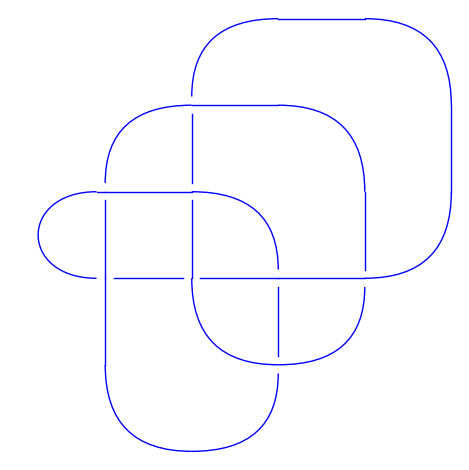

original pd code is [(16, 6, 1, 5), (6, 2, 7, 1), (11, 3, 12, 2), (3, 15, 4, 14), (4, 10, 5, 9), (12, 8, 13, 7), (8, 14, 9, 13), (15, 11, 16, 10)]
arcs are  [[9, 10, 11], [1, 2, 3], [13, 14, 15], [5, 6], [7, 8], [4], [12], [16]]
crossing signs are  [1, 1, 1, 1, 1, 1, 1, 1]
over,under entering, under existing arcs at crossings are  [[4, 8, 2], [2, 4, 5], [2, 1, 7], [3, 2, 6], [1, 6, 4], [5, 7, 3], [3, 5, 1], [1, 3, 8]]


In [189]:
arcs, crossing_signs, arc_crossings = analyze_the_knot(eight_ni_pd)

'''
using the generators first
the generators enormously large for the basis polynomials.
